<a href="https://colab.research.google.com/github/Andy-1402/Simulacion-sistemas-difusos/blob/main/PracticaExperimental_IA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Puerta XOR


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.2588   
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.2524
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2500 - loss: 0.2506
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.2521
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.2532
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.2528
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 0.2517
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.2506
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2500 - loss: 0.2501
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7500 - loss: 0.2502
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.2507
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.2511
Epoch 13/50

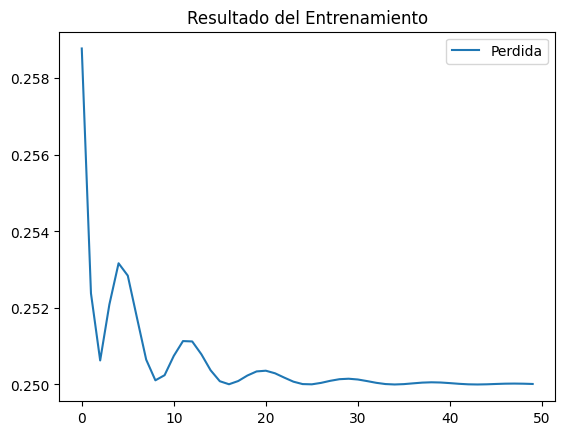

[[-0.90351444 -0.05476765]
 [-0.7919776   0.00996571]]
[0.         0.20994914]
[[ 0.1385603 ]
 [-0.05444731]]
[0.01967489]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.5020609 ]
 [0.50192523]
 [0.50280637]
 [0.5026707 ]]
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[[0.]
 [1.]
 [1.]
 [0.]]


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
# Dataset de entrenamiento para puerta XOR
x_train = np.array([[0,0],[0,1],[1,0],[1,1]], dtype= "float32")
y_train = np.array([[0],[1],[1],[0]], dtype= "float32")
# Modelo MLP
model = keras.Sequential()
model.add(layers.Dense(2, input_dim = 2, activation= 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))
# configuración del modelo
model.compile(optimizer = keras.optimizers.Adam(0.1), loss='mean_squared_error', metrics=['accuracy'])
# Entrenamiento
fit_history = model.fit(x_train, y_train, epochs =50, batch_size=4)
#model.summary()
loss_curve = fit_history.history['loss']
#accuracy_curve = fit_history.history['accuracy']
#plt.plot(accuracy_curve, label = 'precisión')
plt.plot(loss_curve,label='Perdida')
plt.legend(loc='lower left')
plt.legend()
plt.title('Resultado del Entrenamiento')
plt.show()
# Recuperamos bias and weights de la capa oculta
weights_HL, biases_HL = model.layers[0].get_weights()
# Recuperamos bias and weights de la capa de salida
weights_OL, biases_OL = model.layers[1].get_weights()
print(weights_HL)
print(biases_HL)
print(weights_OL)
print(biases_OL)
prediccion = model.predict(x_train)
print(prediccion)
print(x_train)
print(y_train)

#Clasificación Supervisada


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# 1. Cargar dataset real (flores Iris)
iris = load_iris()
X, y = iris.data, iris.target
# 2. Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 3. Entrenar modelo supervisado (KNN)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
# 4. Evaluar
y_pred = model.predict(X_test)
print("Exactitud del modelo:", accuracy_score(y_test, y_pred))
# 5. Predicción con nuevos datos
nueva_flor = [[5.1, 3.5, 1.4, 0.2]]
print("Predicción para la flor nueva:", iris.target_names[model.predict(nueva_flor)][0])

Exactitud del modelo: 1.0
Predicción para la flor nueva: setosa


#Clustering (aprendizaje NO supervisado)

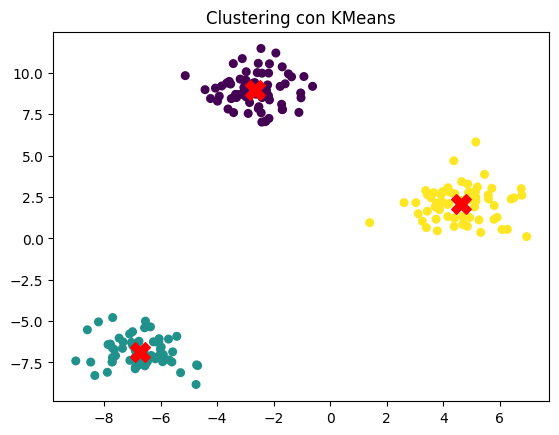

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# 1. Crear datos artificiales
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
# 2. Entrenar modelo no supervisado
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
# 3. Visualizar resultados
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", marker="X", s=200)
plt.title("Clustering con KMeans")
plt.show()

#Red Neuronal Simple - Backpropagation

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
# 1. Datos de entrenamiento (XOR problem)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])
# 2. Crear red neuronal
model = Sequential([
Dense(4, activation='relu', input_shape=(2,)), # capa oculta
Dense(1, activation='sigmoid') # capa de salida
])
# 3. Compilar
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 4. Entrenar
model.fit(X, y, epochs=500, verbose=0)
# 5. Evaluar predicciones
print("Predicciones XOR:")
print(X, "\n", model.predict(X).round())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predicciones XOR:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0 0]
 [0 1]
 [1 0]
 [1 1]] 
 [[0.]
 [0.]
 [1.]
 [1.]]
